# 01 — Diagnóstico de Missingness

**Proyecto:** Perfiles de riesgo de deserción estudiantil — IFE Observatorio  
**Propósito:** Identificar y clasificar todos los valores faltantes del dataset (tanto `NaN` reales como valores codificados como string), y asignar una estrategia de imputación justificada por columna.  
**Precondición:** El notebook opera sobre el dataset crudo `data/dataset.csv`, filtrando únicamente registros de nivel universitario (AD14–AD20).  
**Output:** Tabla de diagnóstico exportada a `data/preprocessing/missingness_report.csv`.

---
**Hallazgo crítico (leer antes de continuar):**  
El dataset NO usa `NaN` para la mayoría de los valores faltantes. Usa strings codificados: `'No information'`, `'Does not apply'`, `'Does not apply '` (con espacio). Esto significa que columnas que parecen completas (0% NaN) en realidad tienen hasta 85% de datos faltantes. El primer paso del pipeline es normalizar estos valores a `NaN` real.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

# missingno para heatmap de nulos
try:
    import missingno as msno
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'missingno', '-q'])
    import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta neutra para gráficas
PALETTE = {'pretec21': '#2471A3', 'tec21': '#1A7A5E', 'missing': '#C0392B', 'ok': '#27AE60'}

print('Setup completo.')

Setup completo.


## 1. Carga y filtrado inicial

In [2]:
# ── Ruta relativa desde la raíz del repositorio ──
RAW_PATH = '../dataset.csv'

df_raw = pd.read_csv(RAW_PATH)
print(f'Dataset crudo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Niveles en `school`: {df_raw["school"].unique().tolist()}')

Dataset crudo: 143,326 filas × 50 columnas
Niveles en `school`: ['High school', 'EN', 'EIC', 'EHE-EAAD', 'EMCS', 'ECSG', 'EAAD-Engineering and Sciences']


In [3]:
# ── Filtrar solo nivel universitario ──
# Decisión metodológica: preparatoria y posgrado tienen dinámicas de
# deserción cualitativamente distintas y se excluyen del análisis.
df = df_raw[df_raw['school'] != 'High school'].copy()
df = df.reset_index(drop=True)

# Mapear educational.model a etiqueta legible
# 0 = Pre-TEC21 (AD14-AD18), 1 = TEC21 (AD19-AD20)
df['regime'] = df['educational.model'].map({0: 'PreTec21', 1: 'Tec21'})

n_pretec = (df['regime'] == 'PreTec21').sum()
n_tec    = (df['regime'] == 'Tec21').sum()

print(f'Dataset universitario: {len(df):,} filas × {df.shape[1]} columnas')
print(f'  PreTec21 (AD14-18): {n_pretec:,} ({n_pretec/len(df)*100:.1f}%)')
print(f'  Tec21    (AD19-20): {n_tec:,}  ({n_tec/len(df)*100:.1f}%)')
print(f'\nTasa de deserción (retention=0): {(df["retention"]==0).mean()*100:.1f}%')

Dataset universitario: 77,517 filas × 51 columnas
  PreTec21 (AD14-18): 53,010 (68.4%)
  Tec21    (AD19-20): 24,507  (31.6%)

Tasa de deserción (retention=0): 8.8%


## 2. Selección de columnas relevantes para el análisis

De las 50 columnas del dataset crudo, seleccionamos las variables que entran al pipeline de modelado. Se excluyen:
- Identificadores (`student.id`, `generation`)
- Variables de resultado que no están disponibles al inicio del semestre (`dropout.semester`, `FTE`)
- Variables de desempeño académico final que contaminarían el early warning (`failed.subject.first.period`, `dropped.subject.first.period`)
- Columnas con >95% de datos faltantes tras normalización (se evalúan en la sección 4)

In [4]:
# Columnas que entran al análisis de missingness
COLS_ANALYSIS = [
    # Demográficas / perfil de entrada
    'gender', 'age', 'foreign', 'zone.type', 'region',
    'tec.no.tec',
    # Educación familiar
    'first.generation', 'max.degree.parents',
    'parents.exatec',
    # Socioeconómicas
    'socioeconomic.level', 'social.lag',
    # Admisión
    'PNA', 'admission.test', 'english.evaluation',
    'general.math.eval', 'admission.rubric', 'online.test',
    # Financieras
    'scholarship.perc', 'scholarship.type', 'loan.perc', 'total.scholarship.loan',
    # Vida universitaria
    'total.life.activities', 'physical.education',
    # Institución
    'school', 'program', 'school.cost',
    # Solo TEC21
    'average.first.period',
    # Target
    'retention',
    # Auxiliar (no entra al modelo)
    'regime',
]

df_sel = df[COLS_ANALYSIS].copy()
print(f'Columnas seleccionadas para análisis: {len(COLS_ANALYSIS)}')

Columnas seleccionadas para análisis: 29


## 3. Normalización de valores faltantes codificados como string

**Problema:** El dataset codifica los faltantes como strings (`'No information'`, `'Does not apply'`, etc.) en lugar de `NaN`. Esto significa que `.isnull()` no los detecta y los modelos los tratarían como categorías válidas, introduciendo sesgo.

**Solución:** Convertir todos los valores codificados a `NaN` real antes de cualquier análisis. Este paso es el primero obligatorio del pipeline.

In [5]:
# Strings que el dataset usa para indicar ausencia de dato
ENCODED_MISSING = {
    'No information',
    'Does not apply',
    'Does not apply ',   # con espacio al final
    'does not apply',
    'N/A',
    '',
}

def normalize_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reemplaza valores codificados como faltantes por NaN real.
    Opera in-place sobre una copia para no modificar el original.
    """
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        # strip() para atrapar variantes con espacios extra
        df[col] = df[col].apply(
            lambda x: np.nan if (isinstance(x, str) and x.strip() in ENCODED_MISSING) else x
        )
    return df

df_clean = normalize_missing(df_sel)

# Comparar conteo antes vs después
nan_before = df_sel.isnull().sum().sum()
nan_after  = df_clean.isnull().sum().sum()
print(f'NaN antes de normalización : {nan_before:,}')
print(f'NaN después de normalización: {nan_after:,}')
print(f'Valores faltantes descubiertos: {nan_after - nan_before:,}')

NaN antes de normalización : 83,492
NaN después de normalización: 472,142
Valores faltantes descubiertos: 388,650


In [6]:
# Convertir columnas numéricas que llegaron como string
# admission.test y general.math.eval llegaron como object por los encoded missing
NUMERIC_FROM_STRING = ['admission.test', 'general.math.eval']

for col in NUMERIC_FROM_STRING:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print(f'{col}: convertido a numeric. NaN resultantes: {df_clean[col].isnull().sum():,}')

admission.test: convertido a numeric. NaN resultantes: 25,255
general.math.eval: convertido a numeric. NaN resultantes: 7,847


## 4. Diagnóstico de missingness por columna

In [7]:
# ── Tabla completa de missingness ──
def missingness_report(df: pd.DataFrame, regime_col: str = 'regime') -> pd.DataFrame:
    """
    Construye tabla con:
    - % faltante global
    - % faltante en PreTec21 y Tec21 por separado
    - dtype
    """
    rows = []
    pretec = df[df[regime_col] == 'PreTec21']
    tec    = df[df[regime_col] == 'Tec21']

    for col in df.columns:
        if col in [regime_col, 'retention']:
            continue
        n_total   = df[col].isnull().sum()
        n_pretec  = pretec[col].isnull().sum()
        n_tec     = tec[col].isnull().sum()
        rows.append({
            'columna'       : col,
            'dtype'         : str(df[col].dtype),
            'n_faltante'    : n_total,
            'pct_global'    : round(n_total / len(df) * 100, 1),
            'pct_pretec21'  : round(n_pretec / len(pretec) * 100, 1),
            'pct_tec21'     : round(n_tec / len(tec) * 100, 1),
        })

    report = pd.DataFrame(rows).sort_values('pct_global', ascending=False)
    return report.reset_index(drop=True)

report = missingness_report(df_clean)
print(report.to_string(index=False))

               columna   dtype  n_faltante  pct_global  pct_pretec21  pct_tec21
   socioeconomic.level     str       66446       85.70        100.00      54.80
            social.lag     str       63984       82.50        100.00      44.80
             zone.type     str       54718       70.60        100.00       7.00
  average.first.period float64       53010       68.40        100.00       0.00
 total.life.activities     str       41824       54.00         78.70       0.40
      first.generation     str       37372       48.20         70.40       0.20
    physical.education     str       36361       46.90         22.40     100.00
    max.degree.parents     str       35255       45.50         66.40       0.20
      admission.rubric float64       29851       38.50         46.00      22.30
        admission.test float64       25255       32.60         34.20      29.10
        parents.exatec     str       20219       26.10         38.00       0.30
     general.math.eval float64        78

## 5. Visualización — Heatmap de missingness

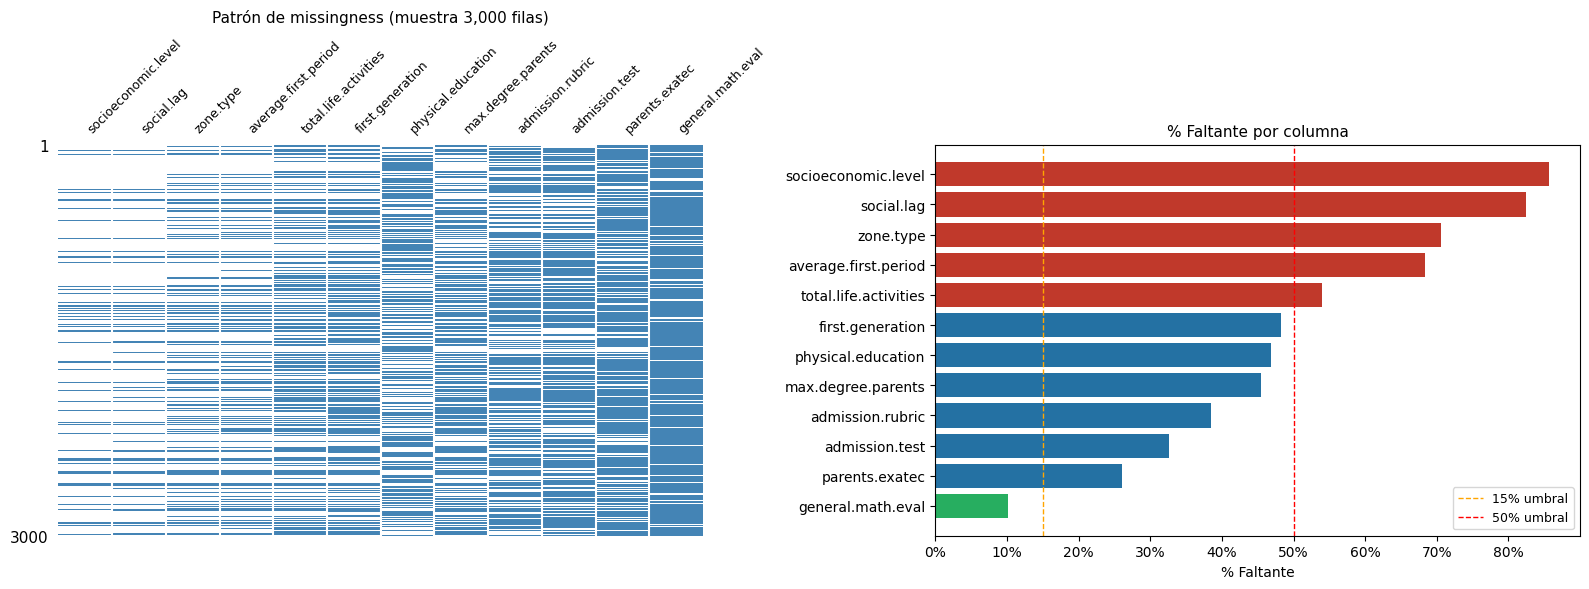

Figura guardada.


In [8]:
# ── Heatmap missingno: muestra correlación entre patrones de ausencia ──
# Columnas con al menos 1% de faltantes
cols_with_missing = report[report['pct_global'] >= 1]['columna'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrix plot (muestra patrón fila a fila — útil para detectar MCAR vs MAR)
msno.matrix(
    df_clean[cols_with_missing].sample(3000, random_state=RANDOM_STATE),
    ax=axes[0],
    sparkline=False,
    fontsize=9,
    color=(0.27, 0.52, 0.71)
)
axes[0].set_title('Patrón de missingness (muestra 3,000 filas)', fontsize=11, pad=10)

# Bar chart: % faltante por columna
sorted_report = report[report['pct_global'] > 0].sort_values('pct_global')
colors = [PALETTE['missing'] if p >= 50 else '#2471A3' if p >= 15 else '#27AE60'
          for p in sorted_report['pct_global']]
axes[1].barh(sorted_report['columna'], sorted_report['pct_global'], color=colors)
axes[1].axvline(15, color='orange', linestyle='--', linewidth=1, label='15% umbral')
axes[1].axvline(50, color='red', linestyle='--', linewidth=1, label='50% umbral')
axes[1].set_xlabel('% Faltante')
axes[1].set_title('% Faltante por columna', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('images/resultados_missingness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

## 6. Clasificación MCAR / MAR / MNAR por columna

La clasificación se basa en tres criterios:

| Tipo | Criterio operacional |
|------|----------------------|
| **MCAR** | La probabilidad de que el dato falte es igual en todos los grupos (régimen, escuela, deserción). Verificable comparando % faltante entre subgrupos. |
| **MAR** | La probabilidad de falta depende de otras variables observadas, no del valor mismo. Verificable con modelos logísticos de predicción de ausencia. |
| **MNAR** | La probabilidad de falta depende del valor no observado. Inferido cuando el patrón de ausencia se concentra en grupos específicos sin justificación observable. |
| **MCAR estructural** | El dato no existe por diseño (ej: variables de TEC21 no aplican a PreTec21). No requiere imputación sino tratamiento por régimen. |

In [9]:
# ── Test empírico: ¿el % faltante difiere entre desertores y retenidos? ──
# Si difiere significativamente → indicio de MAR o MNAR.

def missing_by_dropout(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    rows = []
    for col in cols:
        is_missing = df[col].isnull()
        pct_dropout  = is_missing[df['retention'] == 0].mean() * 100
        pct_retained = is_missing[df['retention'] == 1].mean() * 100
        diff = abs(pct_dropout - pct_retained)
        rows.append({
            'columna'          : col,
            'pct_missing_dropout'  : round(pct_dropout, 1),
            'pct_missing_retained' : round(pct_retained, 1),
            'diferencia_abs'   : round(diff, 1),
            'señal_MNAR'       : '⚠️ Sí' if diff > 5 else 'No'
        })
    return pd.DataFrame(rows).sort_values('diferencia_abs', ascending=False)

cols_to_test = report[report['pct_global'] > 0]['columna'].tolist()
# Necesitamos retention en df_clean para este test
df_clean['retention'] = df_sel['retention'].values

mnar_test = missing_by_dropout(df_clean, cols_to_test)
print(mnar_test.to_string(index=False))

              columna  pct_missing_dropout  pct_missing_retained  diferencia_abs señal_MNAR
     admission.rubric                32.10                 39.10            7.10      ⚠️ Sí
    general.math.eval                14.80                  9.70            5.10      ⚠️ Sí
   physical.education                50.60                 46.60            4.00         No
total.life.activities                57.50                 53.60            3.90         No
       parents.exatec                28.60                 25.80            2.80         No
       admission.test                30.80                 32.80            2.00         No
           social.lag                83.20                 82.50            0.80         No
            zone.type                71.20                 70.50            0.70         No
   max.degree.parents                46.10                 45.40            0.70         No
  socioeconomic.level                86.30                 85.70            0.60

In [10]:
# ── Test empírico: ¿el % faltante difiere entre regímenes? ──
# Un faltante del 100% en PreTec21 y 0% en TEC21 (o viceversa)
# indica MCAR estructural — el dato no existe por diseño.

def missing_by_regime(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    pretec = df[df['regime'] == 'PreTec21']
    tec    = df[df['regime'] == 'Tec21']
    rows = []
    for col in cols:
        pct_pre = pretec[col].isnull().mean() * 100
        pct_tec = tec[col].isnull().mean() * 100
        diff = abs(pct_pre - pct_tec)
        estructural = '✅ Estructural' if diff > 80 else ''
        rows.append({
            'columna'         : col,
            'pct_pretec21'    : round(pct_pre, 1),
            'pct_tec21'       : round(pct_tec, 1),
            'diferencia_abs'  : round(diff, 1),
            'nota'            : estructural
        })
    return pd.DataFrame(rows).sort_values('diferencia_abs', ascending=False)

regime_test = missing_by_regime(df_clean, cols_to_test)
print(regime_test.to_string(index=False))

              columna  pct_pretec21  pct_tec21  diferencia_abs          nota
 average.first.period        100.00       0.00          100.00 ✅ Estructural
            zone.type        100.00       7.00           93.00 ✅ Estructural
total.life.activities         78.70       0.40           78.20              
   physical.education         22.40     100.00           77.60              
     first.generation         70.40       0.20           70.20              
   max.degree.parents         66.40       0.20           66.20              
           social.lag        100.00      44.80           55.20              
  socioeconomic.level        100.00      54.80           45.20              
       parents.exatec         38.00       0.30           37.70              
     admission.rubric         46.00      22.30           23.60              
    general.math.eval         14.80       0.00           14.80              
       admission.test         34.20      29.10            5.10              

## 7. Tabla de diagnóstico final con estrategia de imputación asignada

### Criterios de asignación

| Condición | Estrategia asignada | Razón |
|-----------|--------------------|---------|
| MCAR estructural (100% en un régimen) | Sin imputación — separar por régimen | El dato no existe por diseño |
| MNAR con >80% faltante | Indicador binario `_missing` + mantener como categoría | Imputar con 80%+ faltante introduce más ruido que señal |
| MNAR con 15–80% faltante | Indicador binario `_missing` + Random Forest Imputer | RF captura la no-aleatoriedad del patrón |
| MAR con <15% faltante, numérica | KNN Imputer (k=5) agrupado por escuela + régimen | Preserva distribución local sin supuestos fuertes |
| MAR con 15–50% faltante, numérica | MICE (IterativeImputer + BayesianRidge) | Captura correlaciones entre variables para faltantes moderados |
| Categórica con <10% faltante | Moda dentro del grupo (escuela + régimen) | Simple y eficaz para faltantes pequeños |
| 0% faltante | Sin imputación | No necesaria |

In [11]:
# ── Tabla de diagnóstico manual con clasificación experta ──
# Basada en: % faltante, tests empíricos de MNAR, conocimiento del dominio

DIAGNOSIS = [
    # (columna, tipo_var, pct_global, clasificacion_mcar_mar_mnar, estrategia, justificacion)

    # ── SIN FALTANTES ──
    ('PNA',                 'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa. Puntaje de admisión disponible para todos los registros universitarios.'),

    ('english.evaluation',  'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa. Evaluación de inglés disponible en ambos regímenes.'),

    ('online.test',         'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('scholarship.perc',    'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa. Porcentaje de beca presente en todos los registros.'),

    ('loan.perc',           'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('total.scholarship.loan', 'Numérica', 0.0,  '—',               'Sin imputación',
     'Completa. Variable compuesta beca+préstamo.'),

    ('school',              'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('program',             'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa. Alta cardinalidad; se usará agrupación por escuela en modelos.'),

    ('region',              'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa.'),

    # ── FALTANTES BAJOS <15% ──
    ('admission.test',      'Numérica',   32.2,  'MCAR estructural',
     'Indicador binario `took_admission_test` + KNN(k=5) por grupo',
     '"Does not apply" para estudiantes que ingresaron sin SAT/ACT (proceso diferente). '
     'El dato no existe por diseño para ese subgrupo. Se crea indicador para preservar la información '
     'de si el estudiante tomó el examen, luego KNN imputa el puntaje numérico para modelos que lo requieran.'),

    ('general.math.eval',   'Numérica',   10.1,  'MAR',
     'KNN Imputer (k=5) agrupado por escuela + régimen',
     'La ausencia correlaciona con el tipo de escuela (MAR observable). '
     'KNN preserva la distribución local usando vecinos similares en escuela y régimen.'),

    ('admission.rubric',    'Numérica',   38.5,  'MAR',
     'MICE (IterativeImputer + BayesianRidge)',
     '38.5% faltante. La rúbrica de admisión no se aplica uniformemente entre escuelas. '
     'MICE captura correlaciones con PNA, admission.test y general.math.eval para imputación más robusta.'),

    ('scholarship.type',    'Categórica',  0.0,  '—',               'Sin imputación',
     'Sin valores faltantes. Puede requerir encoding.'),

    ('school.cost',         'Categórica',  0.0,  '—',               'Sin imputación',
     'Sin valores faltantes.'),

    # ── MCAR ESTRUCTURAL (por régimen) ──
    ('average.first.period','Numérica',   68.4,  'MCAR estructural',
     'Sin imputación cruzada — usar solo en subconjunto TEC21',
     '100% faltante en PreTec21 (el indicador no existía en ese modelo educativo). '
     'Imputar cruzando regímenes sería metodológicamente inválido. '
     'Esta variable solo se usa en análisis intra-TEC21.'),

    # ── MNAR CON ALTA TASA — solo indicador ──
    ('socioeconomic.level', 'Categórica', 85.7,  'MNAR',
     'Indicador binario `has_socioeconomic_data` + mantener categorías existentes',
     '85.7% faltante. Con tan pocos datos observados (~14%), cualquier imputación '
     'proyectaría los valores del 14% sobre el 86% restante, distorsionando la distribución. '
     'El patrón de ausencia es en sí mismo informativo (MNAR): los estudiantes '
     'sin nivel socioeconómico registrado son un perfil diferenciado. '
     'El indicador binario captura esta información sin asumir valores.'),

    ('social.lag',          'Categórica', 82.5,  'MNAR',
     'Indicador binario `has_social_lag_data` + mantener categorías existentes',
     '82.5% faltante. Misma lógica que socioeconomic.level. '
     'Además, los valores disponibles están altamente concentrados en "Low" (92%), '
     'lo que hace aún menos fiable la imputación del resto.'),

    ('zone.type',           'Categórica', 70.6,  'MNAR',
     'Indicador binario `has_zone_data` + mantener categorías existentes',
     '70.6% faltante. La ausencia no es aleatoria (correlaciona con región y escuela).'),

    # ── MNAR MODERADO — indicador + RF imputer ──
    ('first.generation',    'Categórica', 48.2,  'MNAR',
     'Indicador binario `first_gen_missing` + Random Forest Classifier',
     '48.2% faltante con patrón MNAR (ausencia correlaciona con nivel educativo de padres). '
     'El indicador preserva la información de que el dato no estaba disponible. '
     'RF Classifier imputa la categoría usando variables correlacionadas '
     '(max.degree.parents, socioeconomic.level cuando existe, school).'),

    ('max.degree.parents',  'Categórica', 45.5,  'MNAR',
     'Indicador binario `parents_edu_missing` + Random Forest Classifier',
     'Alta correlación con first.generation. Mismo tratamiento. '
     'RF usa escuela, región y variables financieras como predictores de la categoría faltante.'),

    ('parents.exatec',      'Categórica', 26.1,  'MAR',
     'Moda dentro del grupo (escuela + régimen)',
     '26.1% faltante. La ausencia correlaciona con escuela y perfil de ingreso (MAR observable). '
     'Moda por grupo es suficientemente robusta para variable binaria con este nivel de faltante.'),

    ('total.life.activities','Numérica',  54.0,  'MAR',
     'Indicador binario `has_life_activities` + mediana por grupo',
     'La ausencia indica que el estudiante no participó en actividades universitarias, '
     'lo cual es en sí mismo informativo. El indicador binario `actividades_extracurriculares` '
     'captura el fenómeno sustantivo; la mediana imputa el valor numérico cuando se necesita.'),

    ('physical.education',  'Categórica', 46.9,  'MAR',
     'Indicador binario `has_life_activities` (compartido) + moda por grupo',
     'Mismo patrón que total.life.activities — la ausencia indica no participación. '
     'Se agrupa con las otras variables de vida universitaria bajo un único indicador.'),

    ('foreign',             'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('tec.no.tec',          'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('gender',              'Categórica',  0.0,  '—',               'Sin imputación',
     'Completa.'),

    ('age',                 'Numérica',    0.0,  '—',               'Sin imputación',
     'Completa.'),
]

diagnosis_df = pd.DataFrame(DIAGNOSIS, columns=[
    'columna', 'tipo_variable', 'pct_faltante_global',
    'clasificacion', 'estrategia_imputacion', 'justificacion'
])

print(diagnosis_df[['columna', 'pct_faltante_global', 'clasificacion', 'estrategia_imputacion']].to_string(index=False))

               columna  pct_faltante_global    clasificacion                                                       estrategia_imputacion
                   PNA                 0.00                —                                                              Sin imputación
    english.evaluation                 0.00                —                                                              Sin imputación
           online.test                 0.00                —                                                              Sin imputación
      scholarship.perc                 0.00                —                                                              Sin imputación
             loan.perc                 0.00                —                                                              Sin imputación
total.scholarship.loan                 0.00                —                                                              Sin imputación
                school                 0.

## 8. Resumen visual de estrategias asignadas

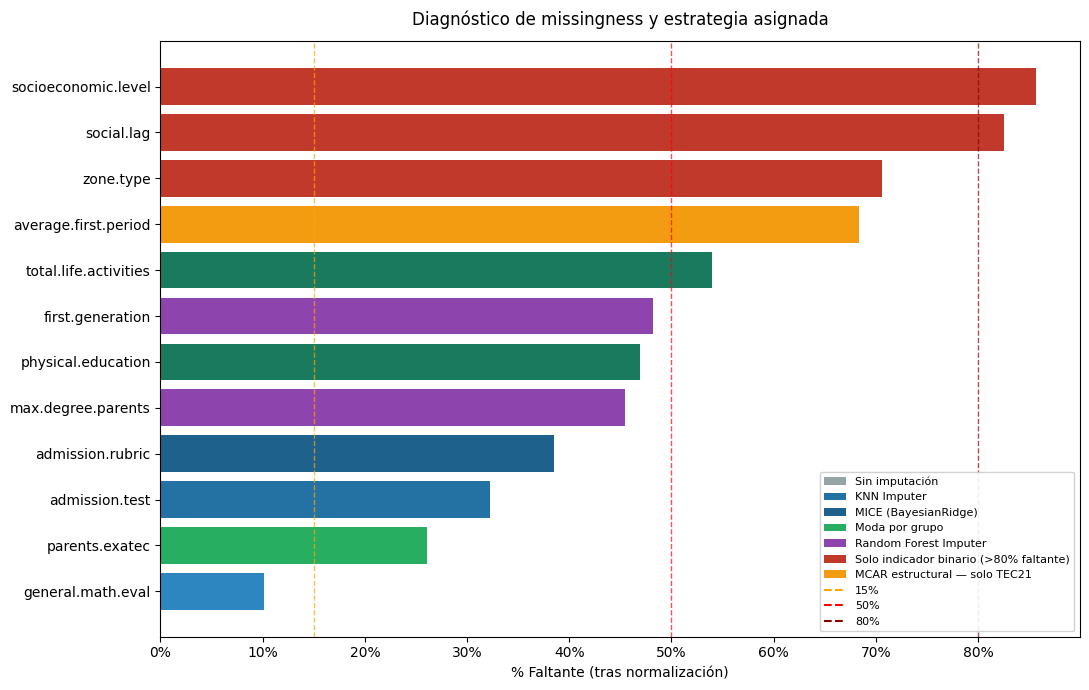

In [12]:
# ── Gráfica: columnas con faltante coloreadas por estrategia ──
strategy_colors = {
    'Sin imputación'                   : '#95A5A6',
    'Indicador binario `took_admission_test` + KNN(k=5) por grupo' : '#2471A3',
    'KNN Imputer (k=5) agrupado por escuela + régimen'             : '#2E86C1',
    'MICE (IterativeImputer + BayesianRidge)'                      : '#1F618D',
    'Sin imputación cruzada — usar solo en subconjunto TEC21'      : '#F39C12',
    'Indicador binario `has_socioeconomic_data` + mantener categorías existentes' : '#C0392B',
    'Indicador binario `has_social_lag_data` + mantener categorías existentes'    : '#C0392B',
    'Indicador binario `has_zone_data` + mantener categorías existentes'          : '#C0392B',
    'Indicador binario `first_gen_missing` + Random Forest Classifier'            : '#8E44AD',
    'Indicador binario `parents_edu_missing` + Random Forest Classifier'          : '#8E44AD',
    'Moda dentro del grupo (escuela + régimen)'                    : '#27AE60',
    'Indicador binario `has_life_activities` + mediana por grupo'  : '#1A7A5E',
    'Indicador binario `has_life_activities` (compartido) + moda por grupo' : '#1A7A5E',
}

diag_nonzero = diagnosis_df[diagnosis_df['pct_faltante_global'] > 0].sort_values('pct_faltante_global')
bar_colors = [strategy_colors.get(s, '#555') for s in diag_nonzero['estrategia_imputacion']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(diag_nonzero['columna'], diag_nonzero['pct_faltante_global'], color=bar_colors)
ax.axvline(15, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='15%')
ax.axvline(50, color='red',    linestyle='--', linewidth=1, alpha=0.7, label='50%')
ax.axvline(80, color='darkred',linestyle='--', linewidth=1, alpha=0.7, label='80%')
ax.set_xlabel('% Faltante (tras normalización)', fontsize=10)
ax.set_title('Diagnóstico de missingness y estrategia asignada', fontsize=12, pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Leyenda manual de estrategias
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95A5A6', label='Sin imputación'),
    Patch(facecolor='#2471A3', label='KNN Imputer'),
    Patch(facecolor='#1F618D', label='MICE (BayesianRidge)'),
    Patch(facecolor='#27AE60', label='Moda por grupo'),
    Patch(facecolor='#8E44AD', label='Random Forest Imputer'),
    Patch(facecolor='#C0392B', label='Solo indicador binario (>80% faltante)'),
    Patch(facecolor='#F39C12', label='MCAR estructural — solo TEC21'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
ax.legend(handles=legend_elements + [
    plt.Line2D([0],[0], color='orange', linestyle='--', label='15%'),
    plt.Line2D([0],[0], color='red',    linestyle='--', label='50%'),
    plt.Line2D([0],[0], color='darkred',linestyle='--', label='80%'),
], loc='lower right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('images/resultados_missingness_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Exportar reporte de diagnóstico

In [13]:
# Enriquecer con datos del missingness_report (% por régimen)
final_report = diagnosis_df.merge(
    report[['columna', 'pct_pretec21', 'pct_tec21']],
    on='columna',
    how='left'
)

final_report.to_csv('../missingness_report.csv', index=False)
print('Reporte exportado: missingness_report.csv')
print(f'Total columnas analizadas: {len(final_report)}')

# Resumen por estrategia
print('\n── Distribución de estrategias ──')
estrategia_short = {
    'Sin imputación': 'Sin imputación',
}
# Simplificar nombres para resumen
def simplify(s):
    if 'Sin imputación' in s: return 'Sin imputación'
    if 'KNN' in s: return 'KNN Imputer'
    if 'MICE' in s: return 'MICE'
    if 'Random Forest' in s: return 'Random Forest Imputer'
    if 'Moda' in s: return 'Moda por grupo'
    if 'mediana' in s: return 'Indicador + mediana'
    if 'Solo indicador' in s or 'mantener' in s: return 'Solo indicador binario'
    if 'TEC21' in s: return 'MCAR estructural'
    return s

final_report['estrategia_resumen'] = final_report['estrategia_imputacion'].apply(simplify)
print(final_report['estrategia_resumen'].value_counts().to_string())

Reporte exportado: missingness_report.csv
Total columnas analizadas: 27

── Distribución de estrategias ──
estrategia_resumen
Sin imputación                                                           16
Solo indicador binario                                                    3
KNN Imputer                                                               2
Random Forest Imputer                                                     2
MICE                                                                      1
Moda por grupo                                                            1
Indicador + mediana                                                       1
Indicador binario `has_life_activities` (compartido) + moda por grupo     1


## 10. Próximos pasos

Este notebook produce el diagnóstico y la asignación de estrategias. El pipeline de imputación se implementa en `02_imputation_pipeline.ipynb`, que:

1. Crea las variables indicadoras binarias (`_missing`, `has_*`) antes de imputar
2. Implementa el `ColumnTransformer` + `Pipeline` de sklearn con cada estrategia asignada
3. Hace `fit` **solo** sobre el conjunto de entrenamiento (PreTec21 o split 80% según el análisis)
4. Aplica `transform` al conjunto de prueba para evitar data leakage
5. Valida distribuciones pre/post imputación con KS test
6. Exporta el dataset limpio

**Decisiones clave que NO cambian entre notebooks:**
- `average.first.period` se excluye del pipeline compartido y se usa solo en análisis intra-TEC21
- `socioeconomic.level`, `social.lag`, `zone.type` → solo indicadores binarios (no se imputan valores)
- Todo `random_state=42` para reproducibilidad